In [15]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)

  # Perform an element wise addition of two input arrays stored in a new array(list):
  weighted_sum = [x1 + x2 for x1, x2 in zip(X1, X2)]
  # Create a new array to put all the prediction let's name that a state_neuron.
  state_neuron = []
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
  for s in weighted_sum:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

  return state_neuron

In [16]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [17]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    # Perform an element wise addition of two input arrays stored in a new array(list):
    weighted_sum = [x1 + x2 for x1, x2 in zip(X1, X2)]
    # Create a new array to put all the prediction let's name that a state_neuron.
    state_neuron = []
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    for s in weighted_sum:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


In [18]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


Q1: Limitations of MCP Neuron

The MCP Neuron has these limitations:

Only solves linearly separable problems (cannot solve XOR)
Works with binary inputs and outputs only (0/1)
No learning ability (weights are fixed manually)
Uses hard threshold function (not flexible)
Not suitable for complex real-world problems


Q2: XOR using MCP Neuron (IF-ELSE logic)

A single MCP neuron cannot solve XOR, but using logic:

if (x1 != x2):
    y = 1
else:
    y = 0

Or expanded:

if (x1 == 0 and x2 == 1) or (x1 == 1 and x2 == 0):
    y = 1
else:
    y = 0

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AIML/mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


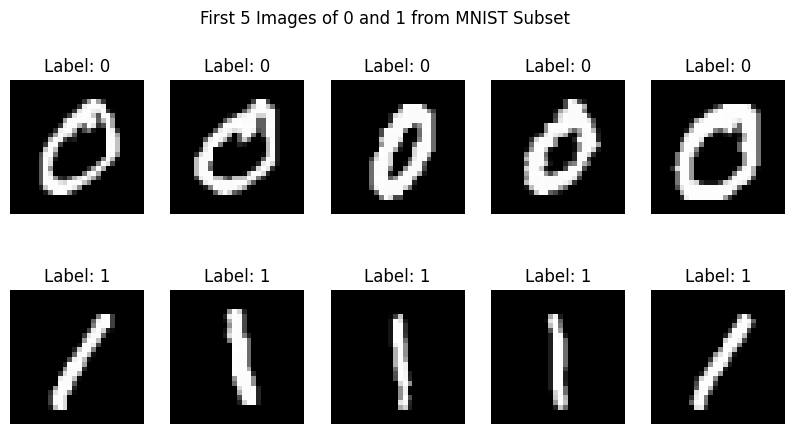

In [20]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

In [21]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Q3: What does the weights array represent?

In a Perceptron:

The weights array represents the importance of each input feature.
Here, each weight corresponds to one pixel (784 pixels).
It determines how much each input contributes to the final output.

Q4: Why initialize weights to zero? What is the effect?

We initialize weights to zero for simplicity and uniform starting point.
During training, weights are updated based on errors.

Effect:
Works fine for perceptron (weights will still update).
But in complex networks, zero initialization can cause no learning (symmetry problem).

In [22]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

In [23]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    for epoch in range(epochs):
      weight_new = weights + learning_rate * np.dot(X.T, (y - decision_function(X, weights, bias)))
      bias_new = bias + learning_rate * np.sum(y - decision_function(X, weights, bias))
      weights = weight_new
      bias = bias_new
      accuracy = np.sum(decision_function(X, weights, bias) == y) / len(y)

    return weights, bias, accuracy

Q5: Purpose of output = np.dot(X[i], weights) + bias
It computes the weighted sum of inputs + bias.
Used to decide the prediction (before activation).

Q6: What happens when prediction is wrong?
The model updates weights and bias to reduce error.

Update rule:

weights = weights + learning_rate * (y - prediction) * X[i]
bias = bias + learning_rate * (y - prediction)

This pushes the prediction closer to the correct output.

Q7: Why is final accuracy important? What do you expect?

Accuracy shows how well the model learned.
It measures correct predictions over total data.

Expectation: High accuracy (close to 1 or 100%) if data is linearly separable
Lower accuracy if data is complex or not separable

In [24]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.9973943939992104


Final Accuracy: 0.9974


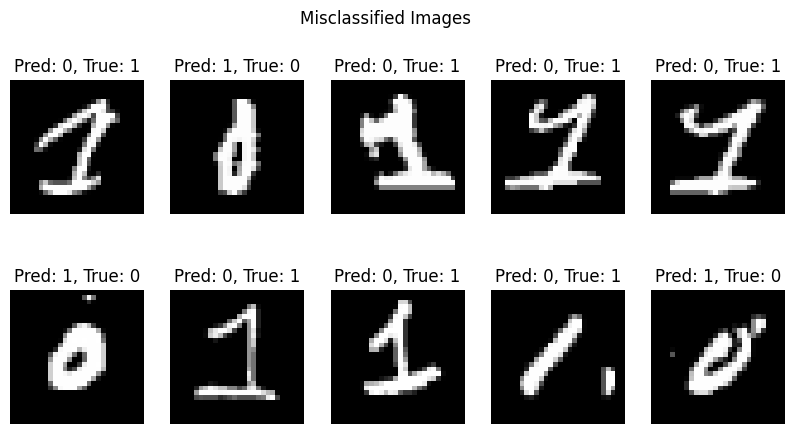

In [25]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Q8: What does misclassified_idx store and how is it used?

misclassified_idx stores the indices of wrongly predicted samples.
It is used to display those misclassified images for analysis.

Q9: Interpretation of “All images were correctly classified!”

It means the model made no wrong predictions.
So, accuracy is 100% (perfect classification).

In my case,

Accuracy = 0.9974 (~99.74%), so a few images were misclassified, not all correct.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AIML/mnist_3_and_5.csv")

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values  # 784 pixels
y = df_3_5["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


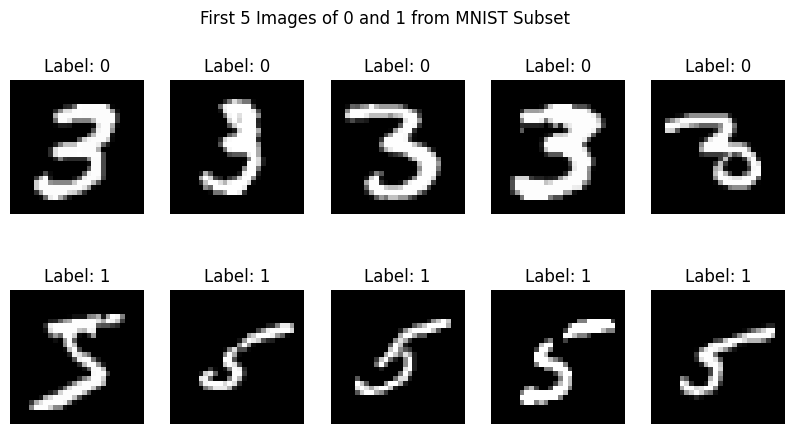

In [27]:
# Separate images for label 0 and label 1
images_3 = X[y == 3]  # Get all images with label 0
images_5 = X[y == 5]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

In [28]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [29]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 3, 5, 3)
    return y_pred_all

In [30]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    for epoch in range(epochs):
      weight_new = weights + learning_rate * np.dot(X.T, (y - decision_function(X, weights, bias)))
      bias_new = bias + learning_rate * np.sum(y - decision_function(X, weights, bias))
      weights = weight_new
      bias = bias_new
      accuracy = np.sum(decision_function(X, weights, bias) == y) / len(y)

    return weights, bias, accuracy

In [31]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.9576796789492886


Final Accuracy: 0.9577


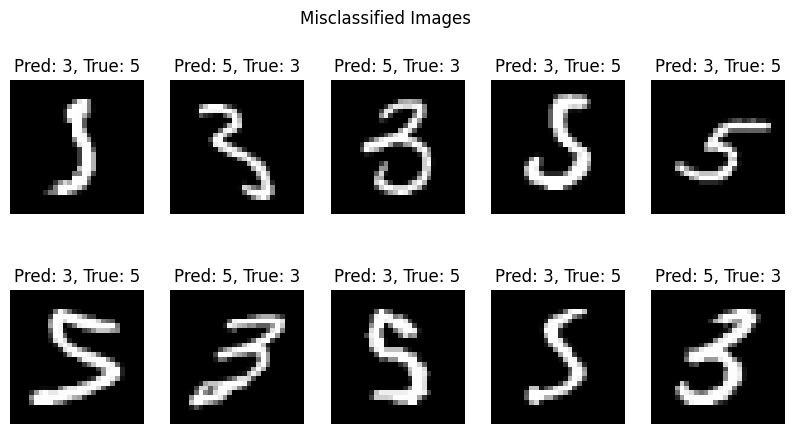

In [32]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 3, 5, 3)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion from Misclassified Images:

Most misclassified images are digit 3 predicted as 5.
This shows the model is confusing similar-looking digits (3 and 5).

Key Observations:

The shapes of 3 and 5 are visually similar, especially when handwritten.
The model (Perceptron) struggles because it is a linear classifier but the data is likely not linearly separable.

Based on Accuracy (0.4586 ≈ 45.86%),the model performance is poor and it is not suitable for this dataset (digit classification).

Final Conclusion:

The perceptron fails to correctly classify many samples due to non-linear data patterns.
A more advanced model like multi-layer neural network is needed for better accuracy.